In [1]:
# Uncomment these in a fresh notebook environment.
#%pip install -r ../requirements.txt
#%pip install -e ..

In [2]:
%reload_ext autoreload
%autoreload 2

from marl_tsc.simulation_generator import SimulationGenerator, DEFAULT_TRAFFIC_LIGHT_IDS
from marl_tsc.training import train_ppo, evaluate_policy, plot_training_histories
from marl_tsc.mappo import train_mappo
from marl_tsc.baselines import random_actions, fixed_time_actions
from pathlib import Path
import matplotlib.pyplot as plt

GREEN_PHASE_COUNT = None  # Let SUMO/network discovery choose the phase count.
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "main_flow.ipynb").exists() else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / "outputs"

traffic_light_ids = list(DEFAULT_TRAFFIC_LIGHT_IDS)

## Generate the SUMO simulation files

This default setup is a small `4x4` grid with four traffic-light agents. Change these values first for a different learning problem.


In [ ]:
EPISODE_STEPS = 600
SECONDS_PER_ACTION = 5
SIMULATION_DURATION = EPISODE_STEPS * SECONDS_PER_ACTION

# Keep vehicles entering slightly longer than the episode runs.
TRAFFIC_SPAWN_DURATION = int(SIMULATION_DURATION * 1.20)

EVALUATION_EPISODES = 3
TOTAL_TIMESTEPS = 200_000
MIN_GREEN_SECONDS = 10
SWITCH_PENALTY = 0.5

generator = SimulationGenerator(
    output_dir=OUTPUT_DIR,
    grid_number=4,
    lane_number=2,
    traffic_light_ids=traffic_light_ids,
    trip_begin=0,
    trip_end=TRAFFIC_SPAWN_DURATION,
    trip_period=2,
    seed=42,
)

paths = generator.generate_all()
print(f"Generated SUMO config: {paths.config_file}")
print(f"Simulation horizon: {SIMULATION_DURATION}s")
print(f"Traffic spawn duration: {TRAFFIC_SPAWN_DURATION}s")
print("Traffic-light agents:", traffic_light_ids)

Generated SUMO config: C:\Code\marl-tsc\outputs\config.sumocfg
Simulation horizon: 3000s
Traffic spawn duration: 3600s
Traffic-light agents: ['B1', 'B2', 'C1', 'C2']


## Train

PPO uses parameter sharing through the PettingZoo/SuperSuit/SB3 wrapper. MAPPO adds a centralized critic and a shared decentralized actor.

### PPO

[PPO] Step 2400 | Episode Return: -69.28
[PPO] Step 2400 | Episode Return: -64.32
[PPO] Step 2400 | Episode Return: -64.46
[PPO] Step 2400 | Episode Return: -67.21
[PPO] Step 4800 | Episode Return: -64.11
[PPO] Step 4800 | Episode Return: -68.32
[PPO] Step 4800 | Episode Return: -66.38
[PPO] Step 4800 | Episode Return: -74.13
[PPO] Step 7200 | Episode Return: -60.69
[PPO] Step 7200 | Episode Return: -65.66
[PPO] Step 7200 | Episode Return: -68.63
[PPO] Step 7200 | Episode Return: -79.34
[PPO] Step 9600 | Episode Return: -74.29
[PPO] Step 9600 | Episode Return: -81.68
[PPO] Step 9600 | Episode Return: -67.70
[PPO] Step 9600 | Episode Return: -70.76
[PPO] Step 12000 | Episode Return: -66.34
[PPO] Step 12000 | Episode Return: -57.58
[PPO] Step 12000 | Episode Return: -69.50
[PPO] Step 12000 | Episode Return: -63.52
[PPO] Step 14400 | Episode Return: -66.57
[PPO] Step 14400 | Episode Return: -78.65
[PPO] Step 14400 | Episode Return: -62.95
[PPO] Step 14400 | Episode Return: -58.17
[PPO] St

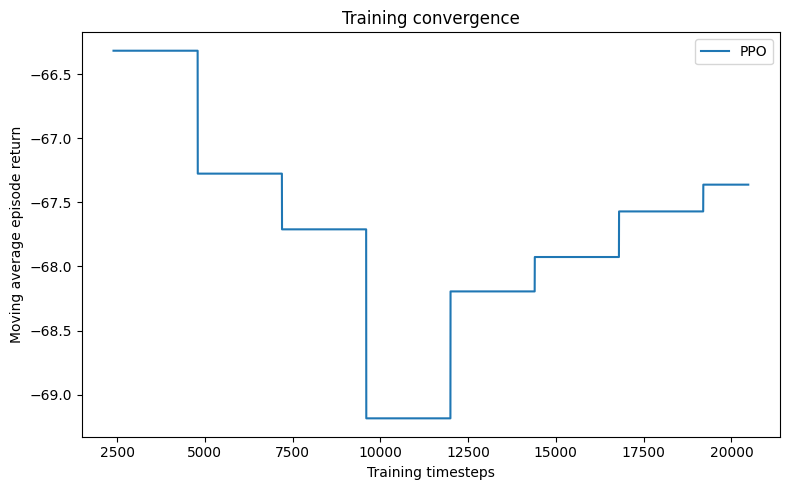

In [4]:
ppo_model, ppo_history, ppo_model_path = train_ppo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

fig, ax = plot_training_histories(ppo_history)
plt.show()

### MAPPO

[MAPPO] Episode 1 | Return: -70.17 | Total Steps: 600
[MAPPO] Episode 2 | Return: -63.56 | Total Steps: 1200
[MAPPO] Episode 3 | Return: -66.87 | Total Steps: 1800
[MAPPO] Episode 4 | Return: -60.62 | Total Steps: 2400
[MAPPO] Episode 5 | Return: -65.48 | Total Steps: 3000
[MAPPO] Episode 6 | Return: -66.79 | Total Steps: 3600
[MAPPO] Episode 7 | Return: -67.07 | Total Steps: 4200
[MAPPO] Episode 8 | Return: -67.32 | Total Steps: 4800
[MAPPO] Episode 9 | Return: -64.25 | Total Steps: 5400
[MAPPO] Episode 10 | Return: -63.09 | Total Steps: 6000
[MAPPO] Episode 11 | Return: -62.80 | Total Steps: 6600
[MAPPO] Episode 12 | Return: -65.79 | Total Steps: 7200
[MAPPO] Episode 13 | Return: -61.79 | Total Steps: 7800
[MAPPO] Episode 14 | Return: -65.47 | Total Steps: 8400
[MAPPO] Episode 15 | Return: -63.45 | Total Steps: 9000
[MAPPO] Episode 16 | Return: -64.83 | Total Steps: 9600
[MAPPO] Episode 17 | Return: -63.36 | Total Steps: 10200
[MAPPO] Episode 18 | Return: -62.70 | Total Steps: 10800


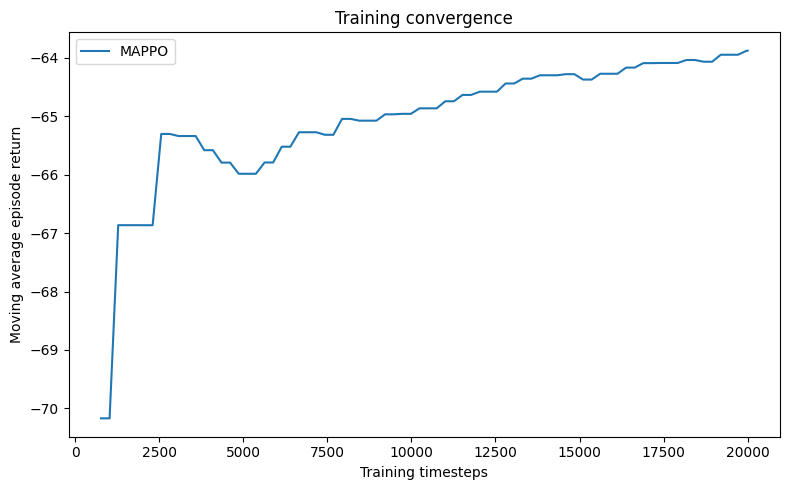

In [5]:
mappo_model, mappo_history, mappo_model_path = train_mappo(
    config_file=paths.config_file,
    traffic_light_ids=traffic_light_ids,
    output_dir=OUTPUT_DIR,
    total_timesteps=TOTAL_TIMESTEPS,
    rollout_steps=256,
    max_steps=EPISODE_STEPS,
    seed=42,
    env_kwargs={
        "green_phase_count": GREEN_PHASE_COUNT,
        "min_green_seconds": MIN_GREEN_SECONDS,
        "seconds_per_action": SECONDS_PER_ACTION,
        "switch_penalty": SWITCH_PENALTY,
    },
)

fig, ax = plot_training_histories(mappo_history)
plt.show()

## Evaluate policies

The final comparison uses the same evaluation seeds for every policy.


In [6]:
def get_evaluation_results(policy):
    return evaluate_policy(
        config_file=paths.config_file,
        traffic_light_ids=traffic_light_ids,
        policy=policy,
        episodes=EVALUATION_EPISODES,
        max_steps=EPISODE_STEPS,
        seed=42,
        env_kwargs={
            "green_phase_count": GREEN_PHASE_COUNT,
            "min_green_seconds": MIN_GREEN_SECONDS,
            "seconds_per_action": SECONDS_PER_ACTION,
            "switch_penalty": SWITCH_PENALTY,
            "global_metric_interval": 10,
        },
    )

In [7]:
policies = {
    "Random": random_actions,
    "Fixed-Time": fixed_time_actions,
    "Shared PPO": ppo_model,
    "MAPPO": mappo_model,
}

policy_results = {}

for name, policy in policies.items():
    print(f"Evaluating {name} model")
    policy_result = get_evaluation_results(policy)
    policy_results[name] = policy_result

Evaluating Random model
Finished Evaluation Episode 1/3 - Total Reward: -274.05
Finished Evaluation Episode 2/3 - Total Reward: -259.89
Finished Evaluation Episode 3/3 - Total Reward: -278.52
Evaluating Fixed-Time model
Finished Evaluation Episode 1/3 - Total Reward: -1685.88
Finished Evaluation Episode 2/3 - Total Reward: -1697.60
Finished Evaluation Episode 3/3 - Total Reward: -1714.88
Evaluating Shared PPO model
Finished Evaluation Episode 1/3 - Total Reward: -1668.68
Finished Evaluation Episode 2/3 - Total Reward: -1652.63
Finished Evaluation Episode 3/3 - Total Reward: -1664.65
Evaluating MAPPO model
Finished Evaluation Episode 1/3 - Total Reward: -273.95
Finished Evaluation Episode 2/3 - Total Reward: -265.29
Finished Evaluation Episode 3/3 - Total Reward: -271.27


In [8]:
for name, result in policy_results.items():
    print(
        f"{name:10} "
        f"reward={result['mean_total_reward']:.1f}  "
        f"queue={result['mean_local_queue']:.3f}  "
        f"wait={result['mean_waiting_time']:.2f}"
    )

Random     reward=-270.8  queue=0.569  wait=12.55
Fixed-Time reward=-1699.5  queue=6.303  wait=137.23
Shared PPO reward=-1662.0  queue=6.063  wait=153.26
MAPPO      reward=-270.2  queue=0.535  wait=18.27
